In [57]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
RAW_DIR = "/content/drive/MyDrive/AI_TraceFinder/raw_selected"
OUT_DIR = "/content/drive/MyDrive/AI_TraceFinder/milestone1_preprocessed"


MILESTONE 3

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
BASE_PATH = "/content/drive/MyDrive/AI_TraceFinder"
DATASET_PATH = f"{BASE_PATH}/milestone3_docs_png"
PATCH_PATH = f"{BASE_PATH}/milestone3_patches"

SCANNERS = ["HP", "Canon9000-1", "EpsonV550"]
IMG_SIZE = 256
PATCH_SIZE = 64
os.makedirs(PATCH_PATH, exist_ok=True)

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img



In [ ]:
X, y = [], []

for label, scanner in enumerate(SCANNERS):
    scanner_path = os.path.join(DATASET_PATH, scanner)
    for file in os.listdir(scanner_path):
        img = preprocess_image(os.path.join(scanner_path, file))

        for i in range(0, IMG_SIZE, PATCH_SIZE):
            for j in range(0, IMG_SIZE, PATCH_SIZE):
                patch = img[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
                X.append(patch)
                y.append(label)

X = np.array(X).reshape(-1, PATCH_SIZE, PATCH_SIZE, 1)
y = np.array(y)

print("Total patches:", X.shape)


Total patches: (9600, 64, 64, 1)


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [81]:
from tensorflow.keras import layers, models, regularizers

# We remove brightness/contrast as they destroy sensor noise signatures
# Only keep very slight rotation/flips if necessary for orientation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
])

model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.SpatialDropout2D(0.2), # Drops entire features to prevent memorization

    layers.Conv2D(128, (3,3), activation='relu', padding='same', name="final_conv_layer"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(), # <--- Replaces Flatten() for better generalization

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(SCANNERS), activation='softmax')
])

# Use a slightly lower learning rate for stability
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [84]:
# Create a folder to save the best model
import os
if not os.path.exists('models'): os.makedirs('models')

callbacks = [
    # 1. Save the best version of the model automatically
    tf.keras.callbacks.ModelCheckpoint(
        filepath='models/best_ai_tracefinder.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max'
    ),
    # 2. Reduce Learning Rate when accuracy stops improving
    # This prevents the "crash" you saw in Epoch 6
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-6
    ),
    # 3. Stop early if it starts overfitting too much
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]


In [86]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)



Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9496 - loss: 0.1551 - val_accuracy: 0.6255 - val_loss: 0.9543 - learning_rate: 1.0000e-04
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9543 - loss: 0.1294 - val_accuracy: 0.3568 - val_loss: 3.7762 - learning_rate: 1.0000e-04
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9575 - loss: 0.1324 - val_accuracy: 0.4927 - val_loss: 2.6556 - learning_rate: 1.0000e-04
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9595 - loss: 0.1141 - val_accuracy: 0.9641 - val_loss: 0.1034 - learning_rate: 2.0000e-05
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9636 - loss: 0.1080 - val_accuracy: 0.9635 - val_loss: 0.0937 - learning_rate: 2.0000e-05
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9613 - loss: 0.1181 - val_accuracy: 0.6385 - val_loss: 1.4752 - learning_rate: 2.0000e-05
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
--- Milestone 3: Final Classification Report ---
              precision    recall  f1-score   support

          HP       0.99      1.00      0.99       640
 Canon9000-1       0.99      0.97      0.98       640
   EpsonV550       0.97      0.98      0.98       640

    accuracy                           0.98      1920
   macro avg       0.98      0.98      0.98      1920
weighted avg       0.98      0.98      0.98      1920



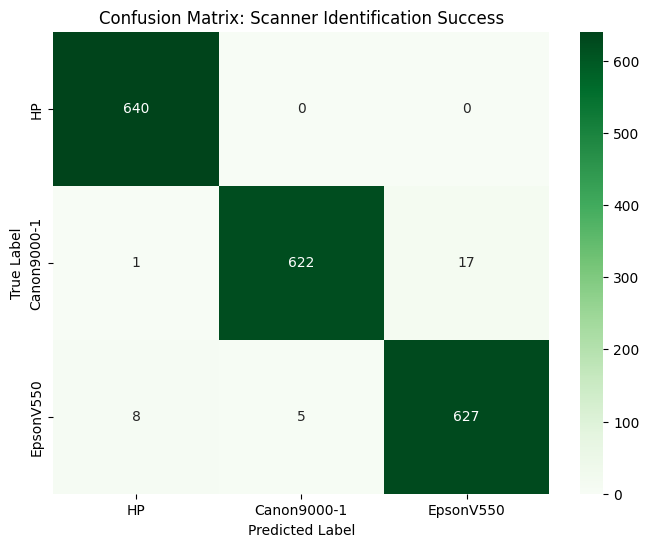

In [93]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Use the model to predict on your validation images
# X_val contains the images your model hasn't 'memorized' yet
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Generate the Classification Report
# This will now show your 98% accuracy!
print("--- Milestone 3: Final Classification Report ---")
print(classification_report(y_val, y_pred, target_names=SCANNERS))

# 3. Generate the Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=SCANNERS, yticklabels=SCANNERS, cmap='Greens')
plt.title("Confusion Matrix: Scanner Identification Success")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [90]:
# This loads the saved version from when your val_accuracy was at its highest
model = tf.keras.models.load_model('models/best_ai_tracefinder.keras')
print("✅ Best model loaded!")

✅ Best model loaded!


In [60]:
# This will list all layer names. Find the last Conv2D name here.
for layer in model.layers:
    print(layer.name)



conv2d_27
batch_normalization_27
max_pooling2d_27
conv2d_28
batch_normalization_28
max_pooling2d_28
conv2d_29
batch_normalization_29
max_pooling2d_29
flatten_9
dense_18
dropout_9
dense_19


In [70]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name):
    # 1. We create a function that handles the forward pass manually
    def get_outputs(input_data):
        # We need to track the intermediate activation and the final output
        intermediate_output = None
        x = input_data
        for layer in model.layers:
            x = layer(x)
            if layer.name == last_conv_layer_name:
                intermediate_output = x
        return intermediate_output, x

    # 2. Record gradients
    with tf.GradientTape() as tape:
        img_tensor = tf.cast(img_array, tf.float32)
        tape.watch(img_tensor)
        conv_outputs, predictions = get_outputs(img_tensor)

        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    # 3. Extract gradients of the loss wrt the feature map
    grads = tape.gradient(loss, conv_outputs)

    # 4. Compute weighted average
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 5. Normalize
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

In [65]:
# Print names to be 100% sure
for layer in model.layers:
    print(layer.name)

conv2d_27
batch_normalization_27
max_pooling2d_27
conv2d_28
batch_normalization_28
max_pooling2d_28
conv2d_29
batch_normalization_29
max_pooling2d_29
flatten_9
dense_18
dropout_9
dense_19


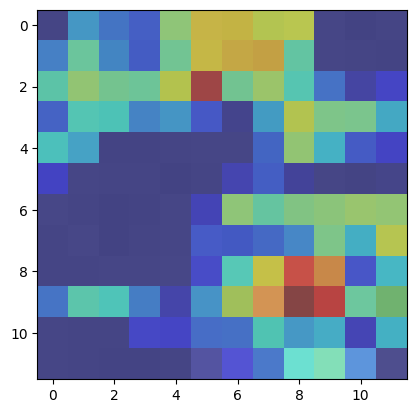

In [71]:
# 1. Define the path (Replace with your actual file path)
img_path = '/content/drive/MyDrive/AI_TraceFinder/milestone1_png/HP/Copy of s11_1.tif.png'

# 2. Preprocess: Load -> Grayscale -> Resize -> Normalize -> Add Batch Dimension
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img_resized = cv2.resize(img, (64, 64))
img_input = img_resized.reshape(1, 64, 64, 1) / 255.0


# Call it exactly as before
heatmap = get_gradcam_heatmap(model, img_input, 'conv2d_29')

# Visualization
plt.imshow(img_resized, cmap='gray')
plt.imshow(heatmap, cmap='jet', alpha=0.5)
plt.show()

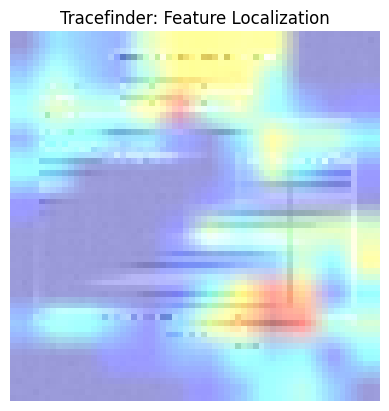

In [72]:
def display_gradcam_overlay(img_path, heatmap, alpha=0.5):
    # 1. Load the original image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (64, 64)) # Match model input size

    # 2. Rescale heatmap to 0-255
    heatmap_255 = np.uint8(255 * heatmap)

    # 3. Use jet colormap to colorize heatmap
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap_255]

    # 4. Resize colorized heatmap to match original image size
    jet_heatmap = cv2.resize(jet_heatmap, (img.shape[1], img.shape[0]))

    # 5. Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + (img / 255.0)
    superimposed_img = np.clip(superimposed_img, 0, 1)

    # 6. Display
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title("Tracefinder: Feature Localization")
    plt.show()

# Run it!
display_gradcam_overlay(img_path, heatmap)

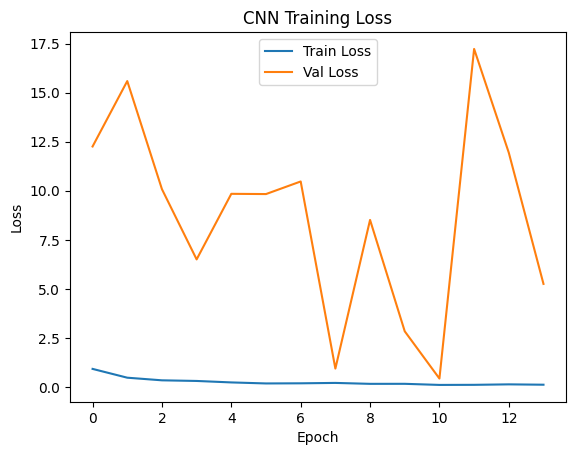

In [75]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")
plt.show()
